# HISEMOTIONS — Fine-tuning BETO / RoBERTa

**Compatible con:** Google Colab (GPU T4) y MacBook Pro M4 (MPS)

Arquitectura:
```
Texto → Tokenizer → BERT encoder → [CLS] → Dropout → Linear(hidden, 6) → Sigmoid
Loss: BCEWithLogitsLoss con pos_weight por clase (corrige desbalance)
```

**Modelos a probar:**
- `dccuchile/bert-base-spanish-wwm-cased` (BETO) ← principal
- `PlanTL-GOB-ES/roberta-base-bne` ← alternativa, más datos de pretraining

In [5]:
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"MPS disponible:  {torch.backends.mps.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    print("Usando Apple Silicon MPS (M4)")
else:
    print("Solo CPU")

# Ver qué device está usando el modelo
print(f"\nDevice del modelo: {next(model.parameters()).device}")


PyTorch: 2.11.0
CUDA disponible: False
MPS disponible:  True
Usando Apple Silicon MPS (M4)


NameError: name 'model' is not defined

In [6]:
# ─── Sólo ejecutar en Google Colab ───────────────────────────────────────────
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'google.colab' in str(get_ipython())

if IN_COLAB:
    !pip install -q transformers accelerate datasets
    # Montar Drive para guardar checkpoints
    from google.colab import drive
    drive.mount('/content/drive')
    # Subir datos (o clonar repo)
    # !git clone https://github.com/davra02/HISEMOTIONS_2026.git
    # %cd HISEMOTIONS_2026
    TRAIN_PATH = 'train/train.csv'
    DEV_PATH   = 'dev/dev.csv'
    OUTPUT_DIR = '/content/drive/MyDrive/HISEMOTIONS/models'
else:
    TRAIN_PATH = '../train/train.csv'
    DEV_PATH   = '../dev/dev.csv'
    OUTPUT_DIR = '../models'

print(f'Colab: {IN_COLAB} | Output: {OUTPUT_DIR}')

Colab: False | Output: ../models


In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import os

EMOTION_COLS = ['anger', 'fear', 'joy', 'sadness', 'surprise', 'hope']

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = get_device()
print(f'Device: {DEVICE}')

Device: mps


## Configuración

In [8]:
CFG = {
    'model_name':    'dccuchile/bert-base-spanish-wwm-cased',
    # 'model_name':  'PlanTL-GOB-ES/roberta-base-bne',  # alternativa
    'max_length':    256,
    'batch_size':    8,
    'num_epochs':    5,
    'learning_rate': 2e-5,
    'dropout':       0.3,
    'warmup_ratio':  0.1,
    'weight_decay':  0.01,
    'seed':          42,
}

CFG['model_name'] = 'FacebookAI/xlm-roberta-large'
CFG['train_path'] = '../train/train_augmented.csv'
CFG['num_epochs'] = 3

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Dataset

In [9]:
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.texts  = df['text'].tolist()
        self.labels = (
            df[EMOTION_COLS].values.astype('float32')
            if all(c in df.columns for c in EMOTION_COLS) else None
        )
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        item = {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
        }
        if 'token_type_ids' in enc:
            item['token_type_ids'] = enc['token_type_ids'].squeeze(0)
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx])
        return item

## 2. Modelo

In [10]:
class MultiLabelEmotionClassifier(nn.Module):
    def __init__(self, model_name, num_labels=6, dropout=0.3):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden          = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask,
                           token_type_ids=token_type_ids)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.classifier(cls)

## 3. pos_weight — compensar el desbalance de clases

In [11]:
def load_split(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=['text']).reset_index(drop=True)
    for col in EMOTION_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype(int)
    return df

train_df = load_split(TRAIN_PATH)
dev_df   = load_split(DEV_PATH)

counts     = train_df[EMOTION_COLS].sum()
n          = len(train_df)
pos_weight = torch.tensor(
    ((n - counts) / counts.clip(lower=1)).values, dtype=torch.float32
).to(DEVICE)

print('pos_weight por emoción:')
for emo, w in zip(EMOTION_COLS, pos_weight.cpu()):
    print(f'  {emo:10s}: {w:.1f}')

pos_weight por emoción:
  anger     : 220.4
  fear      : 7.8
  joy       : 19.6
  sadness   : 1.3
  surprise  : 294.2
  hope      : 35.4


## 4. Tokenizer y DataLoaders

In [12]:
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])

train_ds     = EmotionDataset(train_df, tokenizer, CFG['max_length'])
dev_ds       = EmotionDataset(dev_df,   tokenizer, CFG['max_length'])

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=0)
dev_loader   = DataLoader(dev_ds,   batch_size=CFG['batch_size'], shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Dev batches: {len(dev_loader)}')

Train batches: 333 | Dev batches: 54


## 5. Entrenamiento

In [13]:
model     = MultiLabelEmotionClassifier(CFG['model_name'], dropout=CFG['dropout']).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

total_steps   = len(train_loader) * CFG['num_epochs']
warmup_steps  = int(total_steps * CFG['warmup_ratio'])
optimizer     = torch.optim.AdamW(model.parameters(), lr=CFG['learning_rate'],
                                  weight_decay=CFG['weight_decay'])
scheduler     = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0
    all_logits, all_labels = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            ids   = batch['input_ids'].to(DEVICE)
            mask  = batch['attention_mask'].to(DEVICE)
            ttype = batch.get('token_type_ids')
            if ttype is not None: ttype = ttype.to(DEVICE)
            labs  = batch['labels'].to(DEVICE)

            logits = model(ids, mask, ttype)
            loss   = criterion(logits, labs)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            all_logits.append(logits.detach().cpu().numpy())
            all_labels.append(labs.cpu().numpy())

    return total_loss / len(loader), np.vstack(all_logits), np.vstack(all_labels)

print('Iniciando entrenamiento...')

Iniciando entrenamiento...


In [ ]:
history = {'train_loss': [], 'dev_f1': []}
best_f1, best_thresholds = 0.0, np.full(6, 0.5)
MODEL_PATH = os.path.join(OUTPUT_DIR, 'best_model.pt')

for epoch in range(1, CFG['num_epochs'] + 1):
    train_loss, _, _          = run_epoch(train_loader, train=True)
    _, dev_logits, dev_labels = run_epoch(dev_loader,   train=False)

    # Búsqueda de umbrales
    probs = 1 / (1 + np.exp(-dev_logits))
    thresholds = np.full(6, 0.5)
    for i in range(6):
        best_t, best_score = 0.5, 0.0
        for t in np.arange(0.10, 0.91, 0.05):
            th = thresholds.copy(); th[i] = t
            preds = (probs >= th).astype(int)
            s = f1_score(dev_labels, preds, average='micro', zero_division=0)
            if s > best_score: best_score, best_t = s, t
        thresholds[i] = best_t

    preds = (probs >= thresholds).astype(int)
    dev_f1 = f1_score(dev_labels, preds, average='micro', zero_division=0)

    history['train_loss'].append(train_loss)
    history['dev_f1'].append(dev_f1)
    print(f'Epoch {epoch}/{CFG["num_epochs"]} | loss={train_loss:.4f} | dev micro F1={dev_f1:.4f}')

    if dev_f1 > best_f1:
        best_f1, best_thresholds = dev_f1, thresholds.copy()
        torch.save({'model': model.state_dict(), 'thresholds': thresholds}, MODEL_PATH)
        print(f'  -> Nuevo mejor modelo guardado (F1={best_f1:.4f})')

print(f'\nMejor micro F1 en dev: {best_f1:.4f}')

## 6. Curvas de entrenamiento

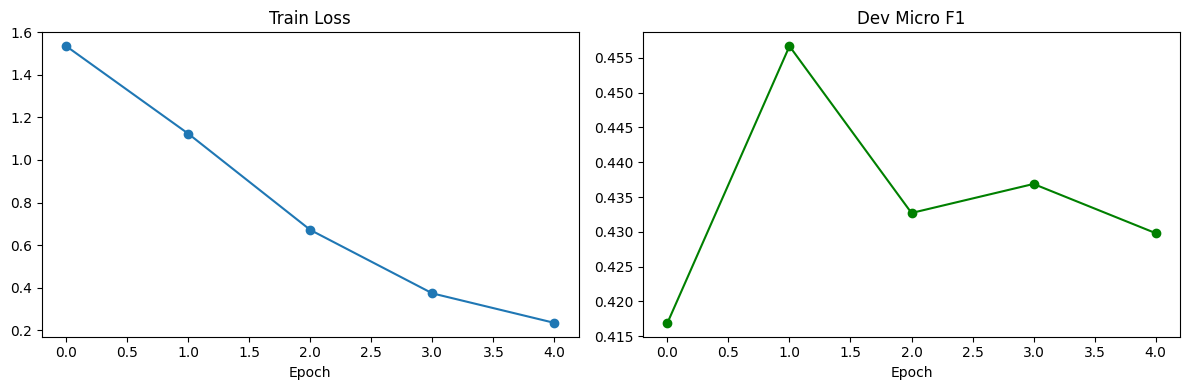

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], marker='o'); axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(history['dev_f1'], marker='o', color='green'); axes[1].set_title('Dev Micro F1'); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

## 7. Evaluación detallada con el mejor modelo

In [13]:
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model'])
best_thresholds = checkpoint['thresholds']

_, dev_logits, dev_labels = run_epoch(dev_loader, train=False)
probs = 1 / (1 + np.exp(-dev_logits))
preds = (probs >= best_thresholds).astype(int)

print('Umbrales finales por emoción:')
for emo, t in zip(EMOTION_COLS, best_thresholds):
    print(f'  {emo:10s}: {t:.2f}')

print(f'\nMicro F1 final: {f1_score(dev_labels, preds, average="micro", zero_division=0):.4f}')
print()
print(classification_report(dev_labels, preds, target_names=EMOTION_COLS, zero_division=0))

Umbrales finales por emoción:
  anger     : 0.35
  fear      : 0.80
  joy       : 0.50
  sadness   : 0.85
  surprise  : 0.40
  hope      : 0.15

Micro F1 final: 0.4567

              precision    recall  f1-score   support

       anger       0.44      0.58      0.50        52
        fear       0.24      0.68      0.35        40
         joy       0.43      0.69      0.53        29
     sadness       0.40      0.71      0.51        70
    surprise       0.00      0.00      0.00         7
        hope       0.38      0.55      0.45        85

   micro avg       0.36      0.61      0.46       283
   macro avg       0.31      0.53      0.39       283
weighted avg       0.37      0.61      0.46       283
 samples avg       0.16      0.30      0.20       283



## 8. Re-entrenamiento final en train+dev (para submission)

> Ejecutar sólo cuando el test set esté disponible y se haya decidido el modelo final.
> Usa los mismos hiperparámetros y los umbrales encontrados en dev.

In [ ]:
# ⚠️  Descomentar sólo para submission final
# full_df      = pd.concat([train_df, dev_df], ignore_index=True)
# full_ds      = EmotionDataset(full_df, tokenizer, CFG['max_length'])
# full_loader  = DataLoader(full_ds, batch_size=CFG['batch_size'], shuffle=True, num_workers=0)
#
# model_final  = MultiLabelEmotionClassifier(CFG['model_name'], dropout=CFG['dropout']).to(DEVICE)
# pos_weight_full = torch.tensor(
#     ((len(full_df) - full_df[EMOTION_COLS].sum()) / full_df[EMOTION_COLS].sum().clip(lower=1)).values,
#     dtype=torch.float32
# ).to(DEVICE)
# criterion_full = nn.BCEWithLogitsLoss(pos_weight=pos_weight_full)
#
# total_s  = len(full_loader) * CFG['num_epochs']
# opt_full = torch.optim.AdamW(model_final.parameters(), lr=CFG['learning_rate'], weight_decay=CFG['weight_decay'])
# sch_full = get_linear_schedule_with_warmup(opt_full, int(total_s*0.1), total_s)
#
# for ep in range(1, CFG['num_epochs']+1):
#     model_final.train()
#     total_loss = 0
#     for batch in full_loader:
#         ids, mask = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE)
#         ttype = batch.get('token_type_ids'); ttype = ttype.to(DEVICE) if ttype is not None else None
#         labs  = batch['labels'].to(DEVICE)
#         opt_full.zero_grad()
#         loss = criterion_full(model_final(ids, mask, ttype), labs)
#         loss.backward(); nn.utils.clip_grad_norm_(model_final.parameters(), 1.0)
#         opt_full.step(); sch_full.step(); total_loss += loss.item()
#     print(f'Epoch {ep}: loss={total_loss/len(full_loader):.4f}')
#
# torch.save({'model': model_final.state_dict(), 'thresholds': best_thresholds},
#            os.path.join(OUTPUT_DIR, 'final_model.pt'))
# print('Modelo final guardado.')
print('Bloque de re-entrenamiento listo — descomentar cuando llegue el test set.')

## 9. Generar predicciones para el test set

In [ ]:
# TEST_PATH = '../test/test.csv'   # o 'test/test.csv' en Colab
#
# test_df   = pd.read_csv(TEST_PATH)
# test_ds   = EmotionDataset(test_df, tokenizer, CFG['max_length'])
# test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=0)
#
# model.eval()
# all_logits = []
# with torch.no_grad():
#     for batch in test_loader:
#         ids, mask = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE)
#         ttype = batch.get('token_type_ids'); ttype = ttype.to(DEVICE) if ttype is not None else None
#         all_logits.append(model(ids, mask, ttype).cpu().numpy())
#
# logits = np.vstack(all_logits)
# probs  = 1 / (1 + np.exp(-logits))
# preds  = (probs >= best_thresholds).astype(int)
#
# submission = test_df[['text']].copy()
# for i, emo in enumerate(EMOTION_COLS):
#     submission[emo] = preds[:, i]
#
# os.makedirs('../submissions', exist_ok=True)
# submission.to_csv('../submissions/run1.csv', index=False)
# print('Submission guardada.')
# print(submission[EMOTION_COLS].sum())
print('Celda de predicción lista — descomentar cuando llegue el test set.')